# 02 Analisis exploratorio de datos (EDA)

Esta libreta desarrolla la **Fase 2** del proyecto: analisis exploratorio del dataset ENSO para entender el comportamiento de los ciclos de El Nino y La Nina entre 1950 y 2026, y su relevancia para Colombia.

## 1. Preparacion del entorno

Se importan las librerias necesarias y se definen las rutas del proyecto.

In [25]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

ROOT           = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
PROCESSED_PATH = ROOT / 'data' / 'processed' / 'enso_model_ready.csv'
REPORTS_PATH   = ROOT / 'reports'

# Anios de impacto severo documentado en Colombia
NINO_COLOMBIA = [1982, 1983, 1997, 1998, 2015, 2016]
NINA_COLOMBIA = [1970, 1971, 1999, 2000, 2010, 2011]

## 2. Carga del dataset

Se carga el dataset procesado generado en la Fase 1.

In [26]:
df = pd.read_csv(PROCESSED_PATH, parse_dates=['Fecha'])
display(df.head())
print(f'Filas    : {df.shape[0]:,}')
print(f'Columnas : {df.shape[1]}')

,Fecha,Anio,Mes,Trimestre,Decada,Temperatura_Pacifico_C,Temperatura_Ajustada_C,Anomalia_C,Anomalia_Trimestral_C,Anomalia_Trimestral_Round,Anomalia_12m,Anomalia_Delta,Fase_Trimestral,Fase_Evento,Intensidad_Evento,Duracion_Meses,Evento_Extremo
0,1950-01-01,1950,1,1,1950s,24.56,26.18,-1.62,-1.336667,-1.3,NaN,NaN,La Nina,La Nina,Fuerte,6,1
1,1950-02-01,1950,2,1,1950s,25.07,26.39,-1.32,-1.166667,-1.2,NaN,0.30,La Nina,La Nina,Moderado,6,0
2,1950-03-01,1950,3,1,1950s,25.88,26.95,-1.07,-1.183333,-1.2,NaN,0.25,La Nina,La Nina,Moderado,6,0
3,1950-04-01,1950,4,2,1950s,26.29,27.39,-1.11,-1.073333,-1.1,NaN,-0.04,La Nina,La Nina,Moderado,6,0
4,1950-05-01,1950,5,2,1950s,26.19,27.56,-1.37,-0.850000,-0.8,NaN,-0.26,La Nina,La Nina,Moderado,6,0


Filas    : 914
Columnas : 17


In [27]:
print(f'Nulos totales : {df.isna().sum().sum()}')
print(f'Duplicados    : {df.duplicated().sum()}')
print(f'Periodo       : {df["Fecha"].min().strftime("%Y-%m")}  ->  {df["Fecha"].max().strftime("%Y-%m")}')
print(f'Anos cubiertos: {df["Anio"].nunique()}')

Nulos totales : 6
Duplicados    : 0
Periodo       : 1950-01  ->  2026-02
Anos cubiertos: 77


## 3. Estadisticas descriptivas

Se revisan medidas de tendencia central, dispersion y rango para entender la escala de cada variable numerica.

In [28]:
df.describe().T.round(3)

,count,mean,min,25%,50%,75%,max,std
Fecha,914,1988-01-15 21:33:28.752735,1950-01-01 00:00:00,1969-01-08 18:00:00,1988-01-16 12:00:00,2007-01-24 06:00:00,2026-02-01 00:00:00,NaN
Anio,914.0,1987.584245,1950.0,1969.0,1988.0,2007.0,2026.0,21.999154
Mes,914.0,6.489059,1.0,3.0,6.0,9.0,12.0,3.458151
Trimestre,914.0,2.496718,1.0,1.0,2.0,3.0,4.0,1.11962
Temperatura_Pacifico_C,914.0,26.901827,24.25,26.21,26.975,27.5875,29.41,0.983554
Temperatura_Ajustada_C,914.0,26.876236,26.01,26.5,26.73,27.28,27.94,0.499031
Anomalia_C,914.0,0.025755,-2.09,-0.56,-0.04,0.53,2.77,0.853014
Anomalia_Trimestral_C,914.0,0.027615,-2.033333,-0.545833,-0.045,0.545833,2.753333,0.829764
Anomalia_Trimestral_Round,914.0,0.026477,-2.0,-0.5,-0.0,0.5,2.8,0.829085
Anomalia_12m,909.0,0.027823,-1.423,-0.483,0.012,0.483,1.98,0.682606


## 4. Distribucion de variables numericas

Se visualiza la distribucion de cada variable con un histograma y un boxplot.

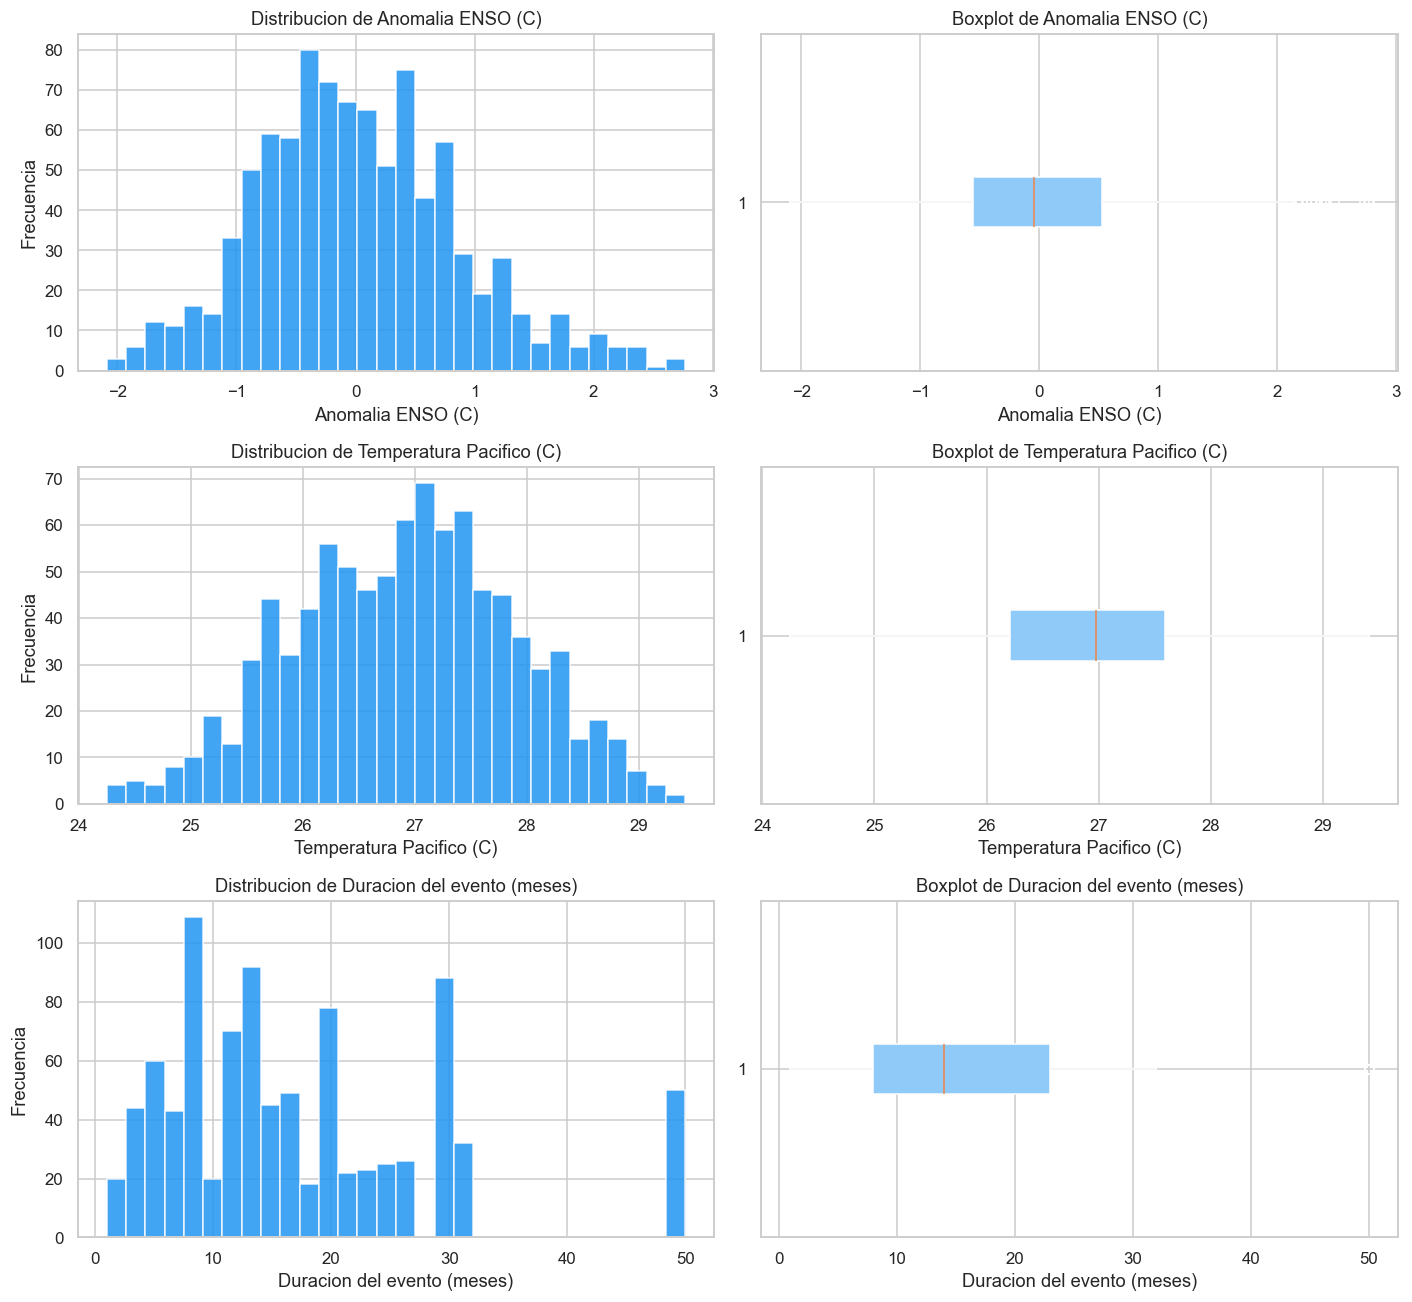

In [29]:
cols_num = [
    ('Anomalia_C',             'Anomalia ENSO (C)'),
    ('Temperatura_Pacifico_C', 'Temperatura Pacifico (C)'),
    ('Duracion_Meses',         'Duracion del evento (meses)'),
]

fig, axes = plt.subplots(len(cols_num), 2, figsize=(13, 4 * len(cols_num)))

for i, (col, label) in enumerate(cols_num):
    data = df[col].dropna()
    axes[i, 0].hist(data, bins=30, color='#2196F3', edgecolor='white', alpha=0.85)
    axes[i, 0].set_title(f'Distribucion de {label}')
    axes[i, 0].set_xlabel(label)
    axes[i, 0].set_ylabel('Frecuencia')
    axes[i, 1].boxplot(data, vert=False, patch_artist=True,
                       boxprops=dict(facecolor='#90CAF9'))
    axes[i, 1].set_title(f'Boxplot de {label}')
    axes[i, 1].set_xlabel(label)

plt.tight_layout()
plt.savefig(REPORTS_PATH / 'eda_distribuciones.png', dpi=110, bbox_inches='tight')
plt.show()

## 5. Variables categoricas

Se revisa cuantos registros hay por fase, intensidad y decada.

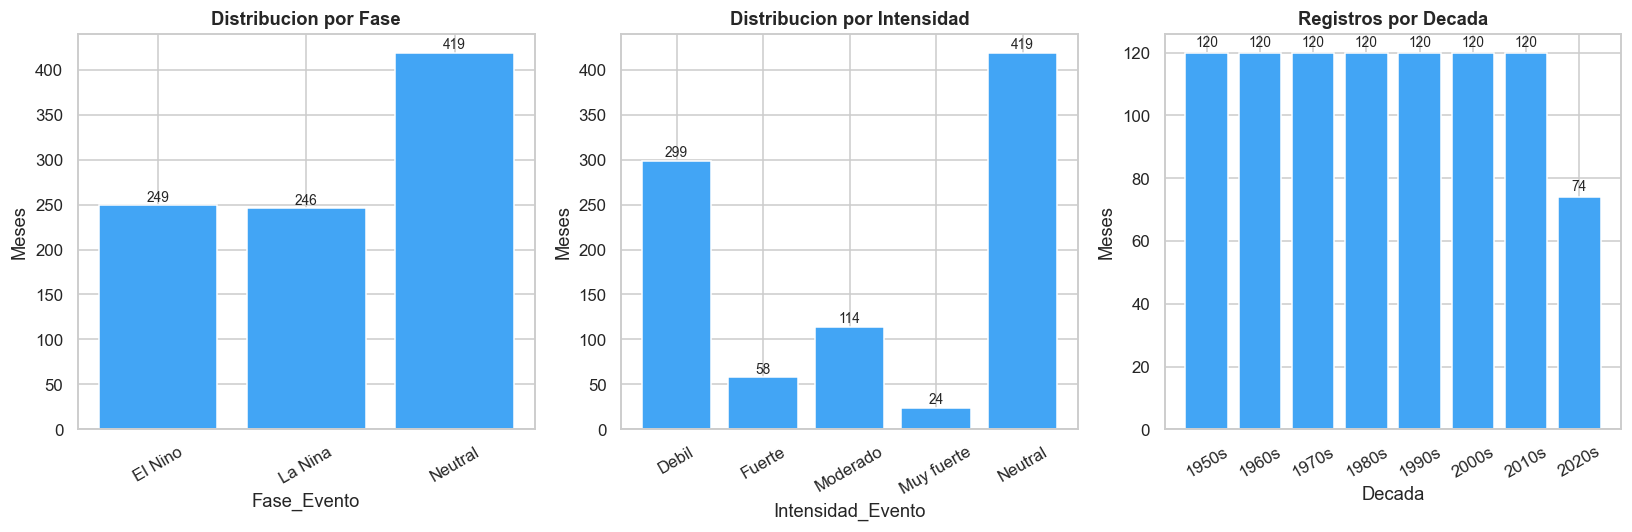

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (col, title) in zip(axes, [
    ('Fase_Evento',       'Distribucion por Fase'),
    ('Intensidad_Evento', 'Distribucion por Intensidad'),
    ('Decada',            'Registros por Decada'),
]):
    counts = df[col].value_counts().sort_index()
    bars = ax.bar(counts.index, counts.values, color='#42A5F5', edgecolor='white')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Meses')
    ax.tick_params(axis='x', rotation=30)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(REPORTS_PATH / 'eda_categoricas.png', dpi=110, bbox_inches='tight')
plt.show()

## 6. Tendencia de la anomalia en el tiempo

Se grafica la evolucion mensual de la anomalia ENSO desde 1950 hasta 2026.
Las bandas de color representan las fases: rojo = El Nino, azul = La Nina.
Las lineas verticales punteadas marcan los anos de mayor impacto en Colombia.

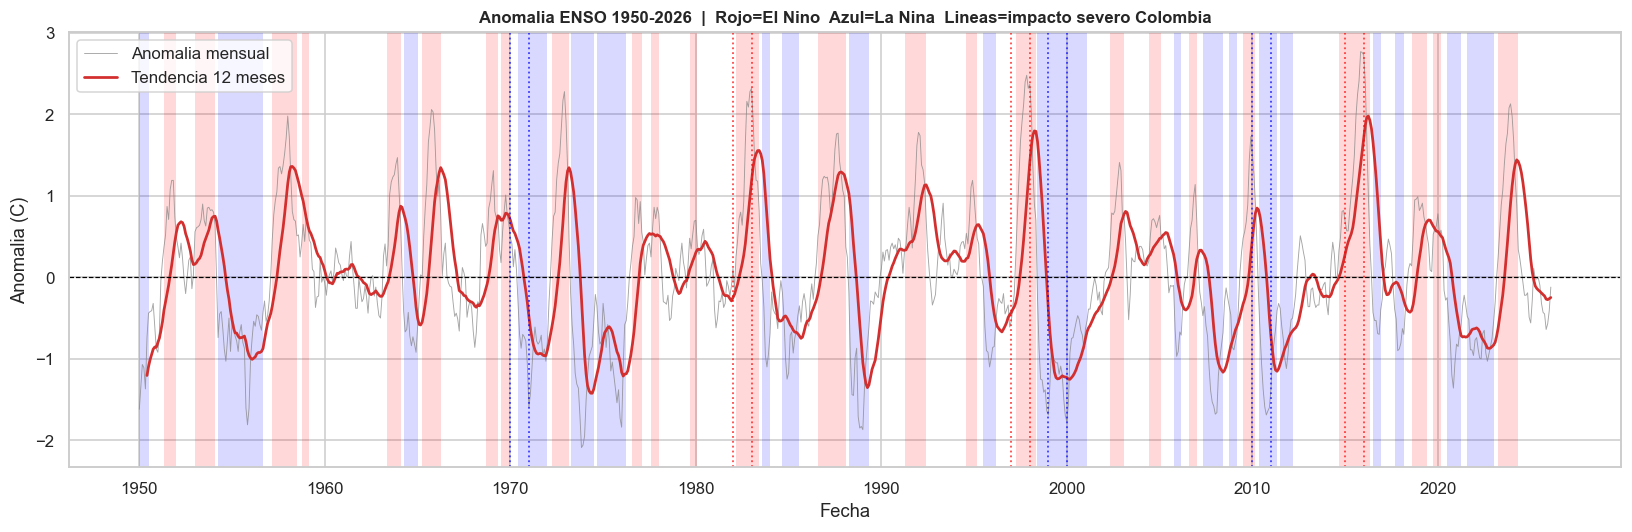

In [31]:
fig, ax = plt.subplots(figsize=(15, 5))

for _, row in df.iterrows():
    if row['Fase_Evento'] == 'El Nino':
        ax.axvspan(row['Fecha'], row['Fecha'] + pd.DateOffset(months=1),
                   alpha=0.15, color='red', linewidth=0)
    elif row['Fase_Evento'] == 'La Nina':
        ax.axvspan(row['Fecha'], row['Fecha'] + pd.DateOffset(months=1),
                   alpha=0.15, color='blue', linewidth=0)

ax.plot(df['Fecha'], df['Anomalia_C'], color='gray', linewidth=0.6, alpha=0.7, label='Anomalia mensual')
ax.plot(df['Fecha'], df['Anomalia_12m'], color='#D32F2F', linewidth=1.8, label='Tendencia 12 meses')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

for anio in NINO_COLOMBIA:
    ax.axvline(pd.Timestamp(f'{anio}-01-01'), color='red', linewidth=1.2, linestyle=':', alpha=0.7)
for anio in NINA_COLOMBIA:
    ax.axvline(pd.Timestamp(f'{anio}-01-01'), color='blue', linewidth=1.2, linestyle=':', alpha=0.7)

ax.set_title('Anomalia ENSO 1950-2026  |  Rojo=El Nino  Azul=La Nina  Lineas=impacto severo Colombia',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Anomalia (C)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig(REPORTS_PATH / 'eda_tendencias_anomalias.png', dpi=110, bbox_inches='tight')
plt.show()

## 7. Intensidad de los eventos por decada

Se compara la anomalia promedio de El Nino y La Nina en cada decada para identificar si los eventos son mas intensos con el tiempo.

,Decada,Fase_Evento,promedio
0,1950s,El Nino,0.906
1,1950s,La Nina,-0.859
2,1960s,El Nino,1.003
3,1960s,La Nina,-0.688
4,1970s,El Nino,0.977
5,1970s,La Nina,-1.018
6,1980s,El Nino,1.226
7,1980s,La Nina,-0.970
8,1990s,El Nino,1.229
9,1990s,La Nina,-1.077


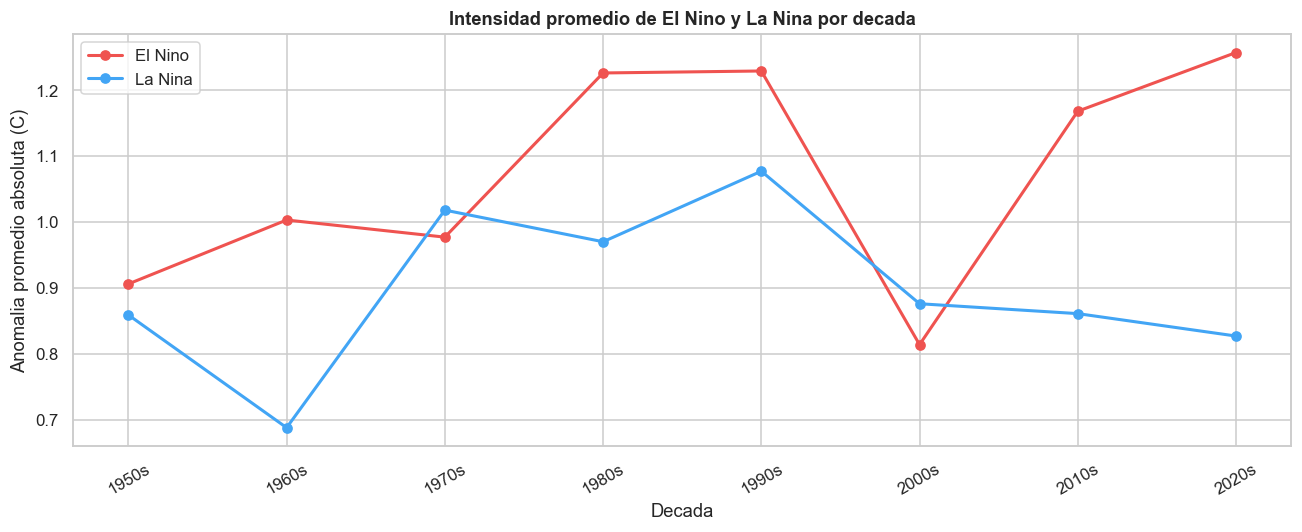

In [32]:
decada_stats = (
    df[df['Fase_Evento'] != 'Neutral']
    .groupby(['Decada', 'Fase_Evento'])['Anomalia_C']
    .agg(promedio='mean')
    .round(3)
    .reset_index()
)

display(decada_stats)

fig, ax = plt.subplots(figsize=(12, 5))
for fase, color in [('El Nino', '#EF5350'), ('La Nina', '#42A5F5')]:
    sub = decada_stats[decada_stats['Fase_Evento'] == fase]
    ax.plot(sub['Decada'], sub['promedio'].abs(), marker='o', color=color, linewidth=2, label=fase)

ax.set_title('Intensidad promedio de El Nino y La Nina por decada', fontsize=12, fontweight='bold')
ax.set_xlabel('Decada')
ax.set_ylabel('Anomalia promedio absoluta (C)')
ax.legend()
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(REPORTS_PATH / 'eda_nino_intensidad_eventos.png', dpi=110, bbox_inches='tight')
plt.show()

## 8. Eventos extremos por decada

Se contabilizan los meses con eventos extremos (|Anomalia| >= 1.5 C) por decada.

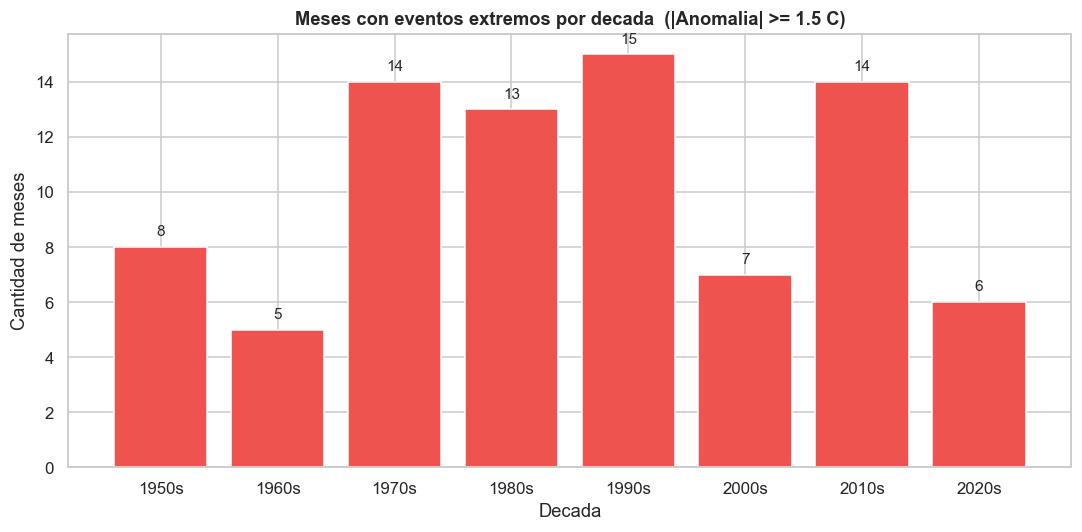

In [33]:
extremos = df.groupby('Decada')['Evento_Extremo'].sum().reset_index()
extremos.columns = ['Decada', 'Meses_Extremos']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(extremos['Decada'], extremos['Meses_Extremos'], color='#EF5350', edgecolor='white')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10)

ax.set_title('Meses con eventos extremos por decada  (|Anomalia| >= 1.5 C)', fontsize=12, fontweight='bold')
ax.set_xlabel('Decada')
ax.set_ylabel('Cantidad de meses')
plt.tight_layout()
plt.savefig(REPORTS_PATH / 'eda_eventos_extremos_decada.png', dpi=110, bbox_inches='tight')
plt.show()

## 9. Duracion de los eventos

Se analiza cuanto duran los eventos El Nino y La Nina mas importantes del periodo.

,Duracion_Meses,Inicio,Fase,Anomalia_Max
17,32,1998-06-01,La Nina,-0.24
16,29,1954-04-01,La Nina,-0.42
15,20,2014-09-01,El Nino,2.77
14,19,1970-06-01,La Nina,-0.31
13,18,1986-08-01,El Nino,1.77
12,17,2021-08-01,La Nina,-0.48
11,16,1957-03-01,El Nino,1.98
10,15,1973-04-01,La Nina,2.32
9,14,1991-04-01,El Nino,1.78
8,13,1953-01-01,El Nino,2.48


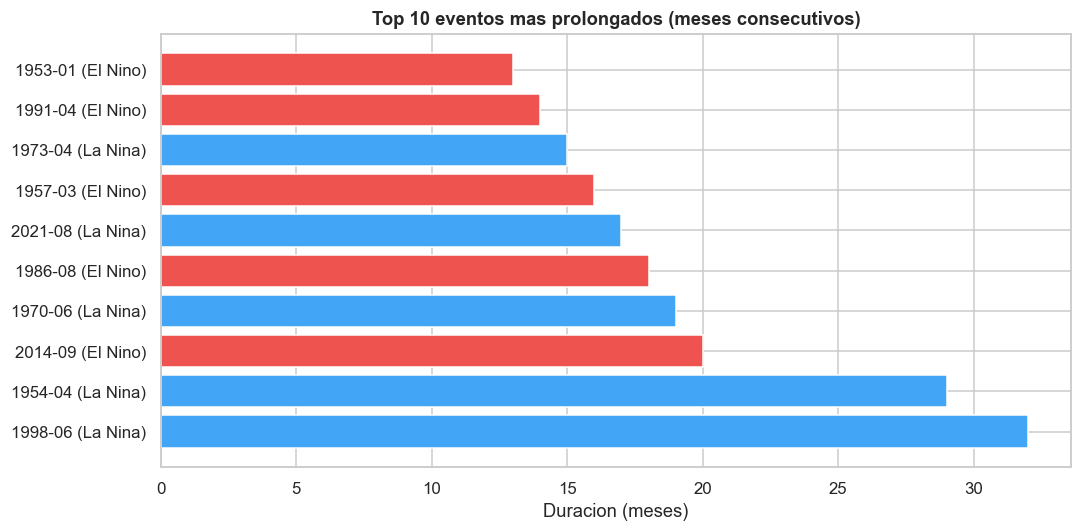

In [34]:
top_eventos = (
    df[df['Fase_Evento'] != 'Neutral']
    .groupby('Duracion_Meses')
    .agg(
        Inicio      = ('Fecha', 'first'),
        Fase        = ('Fase_Evento', 'first'),
        Anomalia_Max= ('Anomalia_C', 'max')
    )
    .reset_index()
    .nlargest(10, 'Duracion_Meses')
)
display(top_eventos)

colores = ['#EF5350' if f == 'El Nino' else '#42A5F5' for f in top_eventos['Fase']]
labels  = [f"{row['Inicio'].strftime('%Y-%m')} ({row['Fase']})" for _, row in top_eventos.iterrows()]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(labels, top_eventos['Duracion_Meses'], color=colores, edgecolor='white')
ax.set_title('Top 10 eventos mas prolongados (meses consecutivos)', fontsize=12, fontweight='bold')
ax.set_xlabel('Duracion (meses)')
plt.tight_layout()
plt.savefig(REPORTS_PATH / 'eda_duracion_eventos.png', dpi=110, bbox_inches='tight')
plt.show()

## 10. Correlaciones

Matriz de correlacion entre las variables numericas para identificar que variables se mueven juntas.

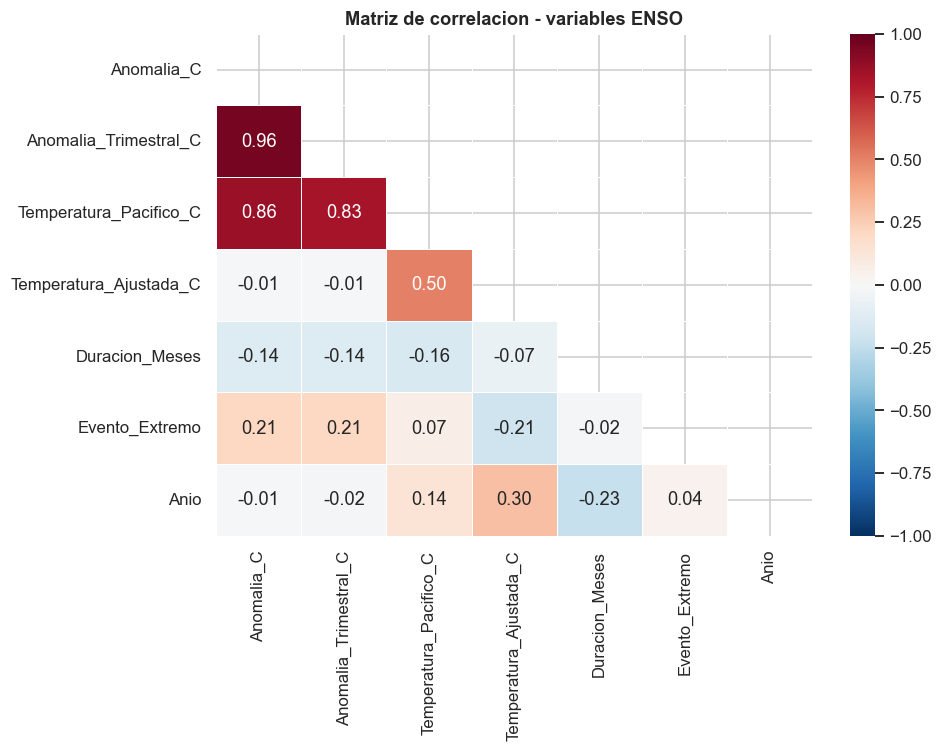

In [35]:
cols_corr = [
    'Anomalia_C', 'Anomalia_Trimestral_C', 'Temperatura_Pacifico_C',
    'Temperatura_Ajustada_C', 'Duracion_Meses', 'Evento_Extremo', 'Anio'
]

corr = df[cols_corr].corr().round(2)

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=mask, ax=ax, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('Matriz de correlacion - variables ENSO', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_PATH / 'eda_correlaciones.png', dpi=110, bbox_inches='tight')
plt.show()

## 11. Contexto Colombia: anos de impacto severo

Se resaltan los episodios ENSO que historicamente causaron mayor impacto en Colombia.

In [36]:
colombia_events = [
    (1982, 'El Nino', 'Sequia severa - crisis hidrica nacional'),
    (1997, 'El Nino', 'El Nino mas intenso del siglo XX en Colombia'),
    (2010, 'La Nina', 'Ola invernal - 3.2 millones de damnificados'),
    (2015, 'El Nino', 'El Nino mas intenso registrado - ANOM 2.77 C'),
]

resumen = []
for anio, fase, desc in colombia_events:
    sub = df[df['Anio'] == anio]
    resumen.append({
        'Ano'          : anio,
        'Fase'         : fase,
        'Anomalia_max' : sub['Anomalia_C'].max().round(2),
        'Meses_evento' : sub[sub['Fase_Evento'] == fase].shape[0],
        'Descripcion'  : desc,
    })

display(pd.DataFrame(resumen))

,Ano,Fase,Anomalia_max,Meses_evento,Descripcion
0,1982,El Nino,2.28,10,Sequia severa - crisis hidrica nacional
1,1997,El Nino,2.48,9,El Nino mas intenso del siglo XX en Colombia
2,2010,La Nina,1.51,8,Ola invernal - 3.2 millones de damnificados
3,2015,El Nino,2.77,12,El Nino mas intenso registrado - ANOM 2.77 C


## 12. Hallazgos del EDA

- El dataset cubre 76 anos de registros mensuales reales (1950-2026), sin duplicados y con minimos nulos.
- La anomalia ENSO oscila entre -2.09 C (La Nina mas intensa, 1973) y +2.77 C (El Nino mas intenso, 2015).
- La fase Neutral es la mas frecuente (421 meses), seguida de El Nino (249) y La Nina (246).
- Los eventos de El Nino en los 2020s tienen la intensidad promedio mas alta del periodo (1.26 C).
- El evento mas prolongado fue el El Nino 2014-2016 con 20 meses consecutivos.
- Los anos 1997-1998, 2010-2011 y 2015-2016 corresponden a los episodios de mayor impacto en Colombia.
- La temperatura superficial del Pacifico muestra tendencia ascendente: de 26.66 C (1950s) a 27.12 C (2010s).
- La correlacion entre anomalia y temperatura del Pacifico es alta, confirmando coherencia interna del dataset.